In [1]:
!pip install -q transformers accelerate bitsandbytes datasets scikit-learn torch huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.6 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, BertForMaskedLM
from sklearn.metrics import f1_score, classification_report
from tqdm import tqdm
from huggingface_hub import login
from google.colab import userdata
import pandas as pd


hf_token = userdata.get('hf_token')
login(token=hf_token)

# Aplicamos el modelo en GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Usando GPU CUDA (Google Colab)")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Usando GPU MPS (Mac Pro M5)")
else:
    device = torch.device("cpu")
    print("Usando CPU")

# Cargamos el conjuto de datos Financial PhraseBank
# El paper utiliza un subconjunto con al menos 75% de acuerdo entre anotadores
print("\nCargando Financial PhraseBank (75% agreement)...")
#dataset = load_dataset("lmassaron/FinancialPhraseBank")
dataset = pd.read_csv('Sentences_AllAgree.csv')


# Mapeo de etiquetas
label_map = {0: "negative", 1: "neutral", 2: "positive"}
inverse_label_map = {"negative": 0, "neutral": 1, "positive": 2}

Usando GPU CUDA (Google Colab)

Cargando Financial PhraseBank (75% agreement)...


In [6]:
true_labels = dataset['labels'].tolist()

In [7]:
# Modelo Base con BERT aplicando Zero SHot y Few sHot
print("\nEvaluando google-bert/bert-base-uncased (Prompting)")
bert_name = "google-bert/bert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_name)
# Cargamos el modelo MLM, no el de clasificación de secuencias
bert_model = BertForMaskedLM.from_pretrained(bert_name).to(device)
bert_model.eval()

# Obtener IDs de los tokens objetivo para la máscara
target_tokens = ["negative", "neutral", "positive"]
target_ids = [bert_tokenizer.convert_tokens_to_ids(t) for t in target_tokens]

def get_bert_prompt_prediction(prompt_text):
    """Obtiene la predicción de BERT para el token [MASK]."""
    inputs = bert_tokenizer(prompt_text, return_tensors="pt", truncation=True, max_length=512).to(device)

    # Encontrar el índice del token [MASK]
    mask_token_index = torch.where(inputs["input_ids"] == bert_tokenizer.mask_token_id)[1]

    with torch.no_grad():
        outputs = bert_model(**inputs)
        logits = outputs.logits

    # Si por truncamiento se pierde la máscara, devolvemos neutral por defecto
    if len(mask_token_index) == 0:
        return 1

    mask_logits = logits[0, mask_token_index, :]

    # Extraer solo los logits de nuestras palabras objetivo (negative, neutral, positive)
    target_logits = mask_logits[0, target_ids]
    pred_idx = torch.argmax(target_logits).item()

    return pred_idx

# Ejecutamos Zero SHot
print("\nEjecutando Zero-Shot Prompting...")
zeroshot_preds = []

for idx, row in tqdm(dataset.iterrows(), desc="BERT Zero-Shot", total=len(dataset)):
    # Plantilla Zero-Shot
    prompt = f"""You're an financial sentiment analyzer and commit no mistakes. Your task is to classify the sentiment of a financial news.
    Sentence: {row['sentences']} The sentiment of this financial news is [MASK]."""
    pred = get_bert_prompt_prediction(prompt)
    zeroshot_preds.append(pred)

print("\nResultados BERT Zero-Shot:")
print("Micro F1:", f1_score(true_labels, zeroshot_preds, average='micro'))
print("Macro F1:", f1_score(true_labels, zeroshot_preds, average='macro'))


# Ejecutamos Few SHOt
print("\nEjecutando Few-Shot Prompting...")
fewshot_preds = []

# Construcción de ejemplos Few-Shot tomados estáticamente del set de entrenamiento para evitar fuga de datos
shot_examples = [
    dataset[dataset['labels'] == 2].iloc[0], # Positive
    dataset[dataset['labels'] == 0].iloc[0], # Negative
    dataset[dataset['labels'] == 1].iloc[0]  # Neutral
]

few_shot_context = " ".join([
    f""" You're an financial sentiment analyzer and commit no mistakes. Your task is to classify the sentiment of a financial news.
    I'll give you a few examples of sentences and their corresponding sentiments.
    Sentence: {ex['sentences']}.
    The sentiment of this financial news is {label_map[ex['labels']]}."""
    for ex in shot_examples
])

for idx, row in tqdm(dataset.iterrows(), desc="BERT Few-Shot", total=len(dataset)):
    # Concatenamos el contexto Few-Shot con la nueva oración a evaluar
    prompt = f"{few_shot_context} Now read the next Sentence: {row['sentences']} The sentiment of this financial news is [MASK]."
    pred = get_bert_prompt_prediction(prompt)
    fewshot_preds.append(pred)

print("\nResultados BERT Few-Shot:")
print("Micro F1:", f1_score(true_labels, fewshot_preds, average='micro'))
print("Macro F1:", f1_score(true_labels, fewshot_preds, average='macro'))

print("\nReporte Comparativo Final (Macro F1)")
print(f"BERT Zero-Shot:     {f1_score(true_labels, zeroshot_preds, average='macro'):.4f}")
print(f"BERT Few-Shot:      {f1_score(true_labels, fewshot_preds, average='macro'):.4f}")


Evaluando google-bert/bert-base-uncased (Prompting)


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: google-bert/bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Ejecutando Zero-Shot Prompting...


BERT Zero-Shot: 100%|██████████| 2264/2264 [00:26<00:00, 86.65it/s]



Resultados BERT Zero-Shot:
Micro F1: 0.6303003533568905
Macro F1: 0.5630620810828245

Ejecutando Few-Shot Prompting...


BERT Few-Shot: 100%|██████████| 2264/2264 [01:12<00:00, 31.39it/s]


Resultados BERT Few-Shot:
Micro F1: 0.536660777385159
Macro F1: 0.44920472002800454

Reporte Comparativo Final (Macro F1)
BERT Zero-Shot:     0.5631
BERT Few-Shot:      0.4492


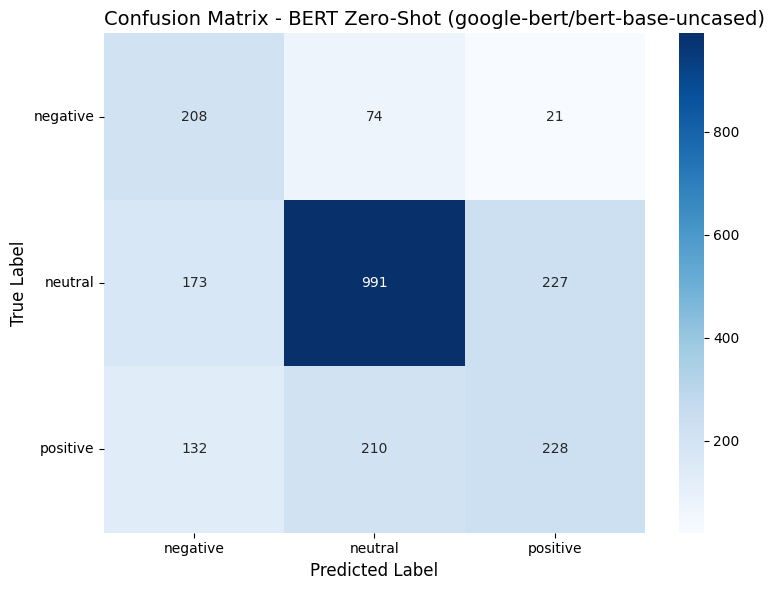

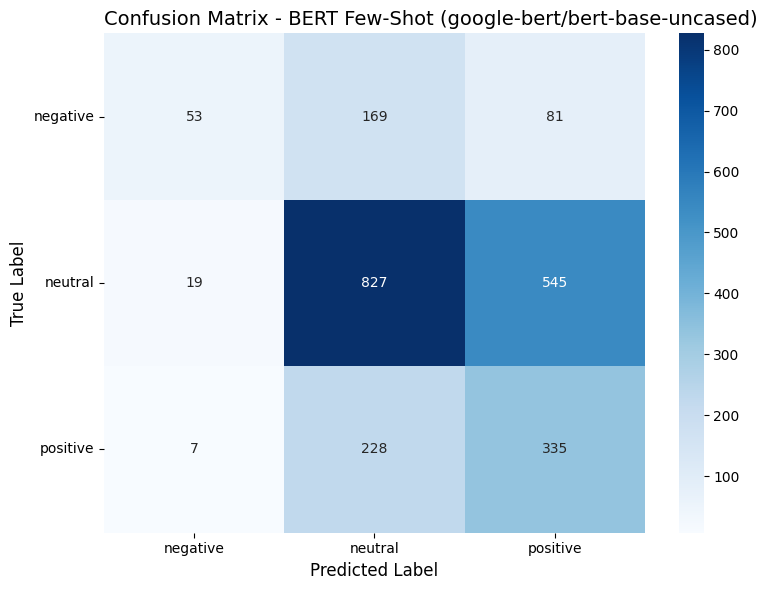

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ensure true_labels are available (assuming they are from the dataset)
# If 'labels' column doesn't exist, this might need adjustment
true_labels = dataset['labels']

# Calculate Confusion Matrices
cm_zeroshot = confusion_matrix(true_labels, zeroshot_preds)
cm_fewshot = confusion_matrix(true_labels, fewshot_preds)

# Label mapping for plots
class_labels = [label_map[i] for i in sorted(label_map.keys())]

# Plotting Zero-Shot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_zeroshot, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - BERT Zero-Shot (google-bert/bert-base-uncased)', fontsize=14, loc='left')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

# Plotting Few-Shot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_fewshot, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - BERT Few-Shot (google-bert/bert-base-uncased)', fontsize=14, loc='left')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()